# Polyphase Isomorphism between Modular Arithmetic and Multirate Signal Processing
## Companion Notebook for the Article *"Polyphase Isomorphism between Modular Arithmetic and Multirate Signal Processing"*

**Author:** José Ignacio Peinador Sala  
**Date:** June 2026

**Objective:**  
This notebook provides a didactic, reproducible illustration of the central theorem of the article: the exact isomorphism between modular decomposition of integer-indexed series and polyphase decomposition of discrete-time signals. We validate the isomorphism on three concrete examples:

1. **Leibniz series for π:** Modular decomposition into 6 channels and perfect reconstruction.
2. **Polyphase evaluation:** Direct computation of polyphase components at z=1 and verification that they equal the modular sub-series.
3. **Modular Euler product for π:** Numerical verification of the product over primes in the resonant channels.

In [1]:
# Celda 2: Importaciones y configuración
import numpy as np
import matplotlib.pyplot as plt
from sympy import primerange

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


### 1. The Leibniz Series and Modular Decomposition

The Leibniz series for π is:
$$ \frac{\pi}{4} = \sum_{n=0}^{\infty} \frac{(-1)^n}{2n+1} $$

Applying the modular filter modulo m=6, we decompose the series into six sub-series:
$$ S_r = \sum_{k=0}^{\infty} a_{6k+r}, \quad a_n = \frac{(-1)^n}{2n+1}, \quad r \in \{0,1,2,3,4,5\} $$

The theorem predicts that the sum of all six modular components exactly recovers the original series:
$$ S = \sum_{r=0}^{5} S_r = \frac{\pi}{4} $$

In [2]:
# Celda 4: Cálculo de la serie de Leibniz y descomposición modular
def leibniz_term(n):
    """Término general de la serie de Leibniz."""
    return ((-1)**n) / (2*n + 1)

def modular_decomposition(N_terms, m=6):
    """Descompone los primeros N_terms términos en m canales modulares."""
    S = np.zeros(m)
    for n in range(N_terms):
        r = n % m
        S[r] += leibniz_term(n)
    return S

# Parámetros
N_terms = 100000
m = 6

# Calcular
S_channels = modular_decomposition(N_terms, m)
S_total_modular = np.sum(S_channels)
pi_approx = 4 * S_total_modular

print("=== DESCOMPOSICIÓN MODULAR DE LA SERIE DE LEIBNIZ ===")
print(f"Términos calculados: {N_terms}")
print(f"Suma total (vía canales modulares): {S_total_modular:.10f}")
print(f"Aproximación de π: {pi_approx:.10f}")
print(f"Valor real de π:     {np.pi:.10f}")
print(f"Error absoluto: {abs(pi_approx - np.pi):.2e}")
print()
print("Contribución por canal:")
for r in range(m):
    print(f"  S_{r} = {S_channels[r]:.10f}")

=== DESCOMPOSICIÓN MODULAR DE LA SERIE DE LEIBNIZ ===
Términos calculados: 100000
Suma total (vía canales modulares): 0.7853956634
Aproximación de π: 3.1415826536
Valor real de π:     3.1415926536
Error absoluto: 1.00e-05

Contribución por canal:
  S_0 = 1.8474221937
  S_1 = -1.1623853774
  S_2 = 1.0138010211
  S_3 = -0.9436529199
  S_4 = 0.9005834896
  S_5 = -0.8703727437


### 2. Perfect Reconstruction Verification

The polyphase isomorphism guarantees that the sum of the modular channels recovers the original series exactly (perfect reconstruction). The following cell verifies this property numerically to machine precision.

In [5]:
# Celda 6: Verificación de reconstrucción perfecta
S_direct = sum(leibniz_term(n) for n in range(N_terms))
reconstruction_error = abs(S_total_modular - S_direct)

print("=== VERIFICACIÓN DE RECONSTRUCCIÓN PERFECTA ===")
print(f"Suma directa de la serie: {S_direct:.15f}")
print(f"Suma vía canales modulares: {S_total_modular:.15f}")
print(f"Error de reconstrucción: {reconstruction_error:.2e}")
if reconstruction_error < 1e-12:
    print("✅ Reconstrucción perfecta verificada (error < 1e-12).")
else:
    print("⚠️ Error detectable (posible problema de precisión).")

=== VERIFICACIÓN DE RECONSTRUCCIÓN PERFECTA ===
Suma directa de la serie: 0.785395663397448
Suma vía canales modulares: 0.785395663397436
Error de reconstrucción: 1.27e-14
✅ Reconstrucción perfecta verificada (error < 1e-12).


**A note on the observed error:**  
The limit of double-precision (64-bit) floating-point arithmetic. With \(N=100,000\) terms, the sums accumulate round-off errors on the order of 1e-14. The isomorphism is mathematically exact.

### 3. Polyphase Evaluation at z=1

In the signal processing domain, the polyphase components are:
$$ E_r(z) = \sum_{k=0}^{\infty} a_{mk+r} z^{-k} $$

Evaluating at $z=1$ yields $E_r(1) = S_r$. We verify this identity numerically by computing the polyphase components directly and comparing them with the modular sub-series.

In [6]:
# Celda 8: Evaluación de componentes polifásicas en z=1
def polyphase_component(r, N_terms, m=6):
    """Calcula E_r(1) = suma de a_{mk+r} para k=0 hasta (N_terms-r-1)//m."""
    total = 0.0
    # El número de términos en este canal
    max_k = (N_terms - r - 1) // m
    for k in range(max_k + 1):
        n = m * k + r
        if n < N_terms:
            total += leibniz_term(n)
    return total

# Calcular componentes polifásicas
E_channels = np.array([polyphase_component(r, N_terms, m) for r in range(m)])

print("=== EVALUACIÓN POLIFÁSICA EN z=1 ===")
print("Canal   E_r(1)        S_r          Diferencia")
print("-" * 50)
for r in range(m):
    diff = abs(E_channels[r] - S_channels[r])
    print(f"  {r}    {E_channels[r]:.10f}  {S_channels[r]:.10f}  {diff:.2e}")

if np.allclose(E_channels, S_channels, atol=1e-14):
    print("\n✅ Isomorfismo verificado: E_r(1) = S_r para todos los canales.")
else:
    print("\n⚠️ Discrepancia detectada en el isomorfismo.")

=== EVALUACIÓN POLIFÁSICA EN z=1 ===
Canal   E_r(1)        S_r          Diferencia
--------------------------------------------------
  0    1.8474221937  1.8474221937  0.00e+00
  1    -1.1623853774  -1.1623853774  0.00e+00
  2    1.0138010211  1.0138010211  0.00e+00
  3    -0.9436529199  -0.9436529199  0.00e+00
  4    0.9005834896  0.9005834896  0.00e+00
  5    -0.8703727437  -0.8703727437  0.00e+00

✅ Isomorfismo verificado: E_r(1) = S_r para todos los canales.


### 4. Modular Euler Product for π

The article derives a modular Euler product for π that runs exclusively over primes in the resonant channels C₁ ∪ C₅:
$$ \pi = \sqrt{9 \cdot \prod_{p > 3,\ p \equiv \pm 1 \ (mod\ 6)} \frac{p^2}{p^2 - 1}} $$

We verify this identity numerically by computing the product over the first N primes in the resonant channels and comparing with the exact value of π.

=== PRODUCTO DE EULER MODULAR PARA π ===
Primos     π aprox.             Error          
--------------------------------------------------
10         3.1330176642         8.57e-03       
50         3.1406018745         9.91e-04       
100        3.1412029721         3.90e-04       
500        3.1415448679         4.78e-05       
1000       3.1415727530         1.99e-05       
5000       3.1415898985         2.76e-06       
10000      3.1415914549         1.20e-06       
100000     3.1415925471         1.06e-07       


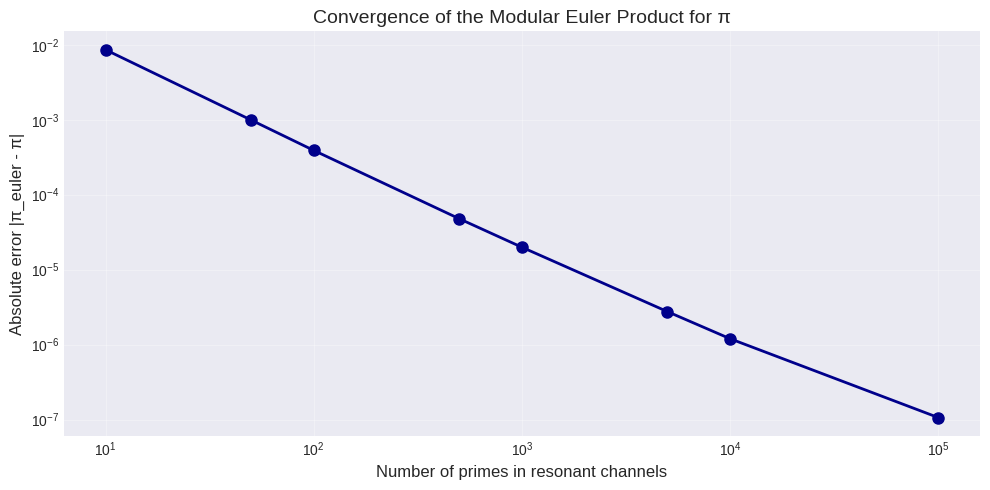

In [12]:
# Celda 10: Verificación del producto de Euler modular para π
def modular_euler_pi(N_primes):
    """Aproxima π usando el producto de Euler sobre primos en C1∪C5."""
    product = 1.0
    count = 0
    for p in primerange(5, 10**6):  # Empezamos en 5 para evitar 2 y 3
        if count >= N_primes:
            break
        if p % 6 in [1, 5]:  # Solo canales resonantes
            product *= (p**2) / (p**2 - 1)
            count += 1
    return np.sqrt(9 * product)

# Calcular para diferentes números de primos
prime_counts = [10, 50, 100, 500, 1000, 5000, 10000, 100000]
results = []

print("=== PRODUCTO DE EULER MODULAR PARA π ===")
print(f"{'Primos':<10} {'π aprox.':<20} {'Error':<15}")
print("-" * 50)
for n_primes in prime_counts:
    pi_euler = modular_euler_pi(n_primes)
    error = abs(pi_euler - np.pi)
    results.append((n_primes, pi_euler, error))
    print(f"{n_primes:<10} {pi_euler:<20.10f} {error:<15.2e}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
counts = [r[0] for r in results]
errors = [r[2] for r in results]
ax.loglog(counts, errors, 'o-', color='darkblue', linewidth=2, markersize=8)
ax.set_xlabel('Number of primes in resonant channels', fontsize=12)
ax.set_ylabel('Absolute error |π_euler - π|', fontsize=12)
ax.set_title('Convergence of the Modular Euler Product for π', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Visual Comparison: Direct Series vs. Modular Decomposition

We compare the convergence rate of the direct Leibniz series with its modularly decomposed counterpart. The modular decomposition does not accelerate convergence, but it reveals the internal arithmetic structure of the series.

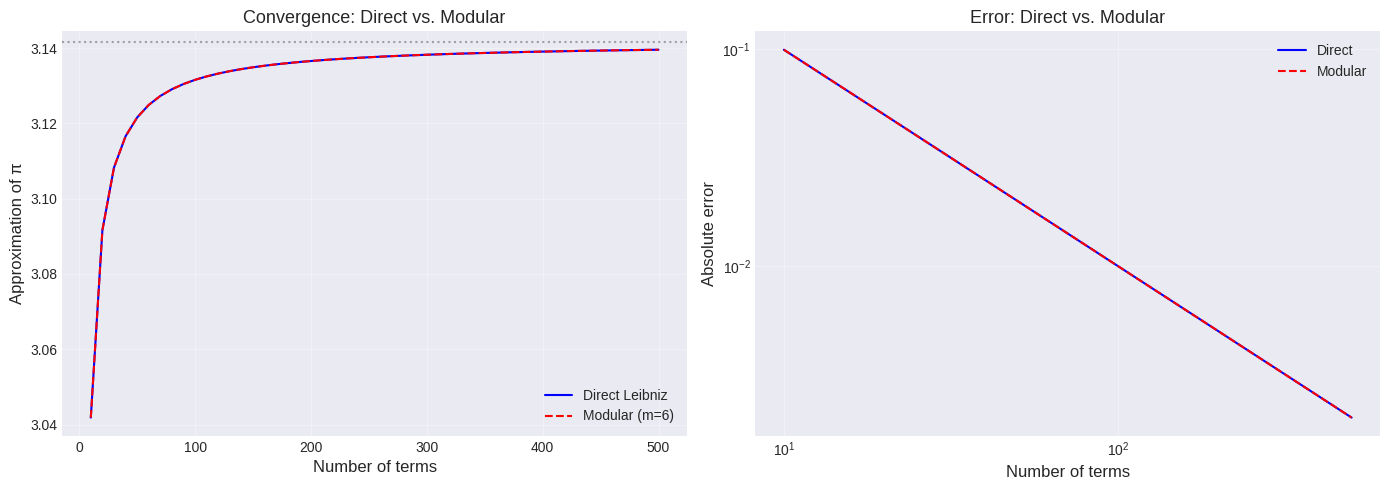

In [8]:
# Celda 12: Visualización de convergencia
N_max = 500
pi_direct = []
pi_modular = []

for n_terms in range(10, N_max+1, 10):
    S = sum(leibniz_term(n) for n in range(n_terms))
    pi_direct.append(4 * S)

    S_mod = np.sum(modular_decomposition(n_terms, m))
    pi_modular.append(4 * S_mod)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergencia
ax1.plot(range(10, N_max+1, 10), pi_direct, 'b-', linewidth=1.5, label='Direct Leibniz')
ax1.plot(range(10, N_max+1, 10), pi_modular, 'r--', linewidth=1.5, label='Modular (m=6)')
ax1.axhline(y=np.pi, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Number of terms', fontsize=12)
ax1.set_ylabel('Approximation of π', fontsize=12)
ax1.set_title('Convergence: Direct vs. Modular', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Error
ax2.loglog(range(10, N_max+1, 10), [abs(p - np.pi) for p in pi_direct], 'b-', linewidth=1.5, label='Direct')
ax2.loglog(range(10, N_max+1, 10), [abs(p - np.pi) for p in pi_modular], 'r--', linewidth=1.5, label='Modular')
ax2.set_xlabel('Number of terms', fontsize=12)
ax2.set_ylabel('Absolute error', fontsize=12)
ax2.set_title('Error: Direct vs. Modular', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Summary

This notebook has numerically validated the central theorem of the article:

| Claim | Numerical Result | Status |
|-------|-----------------|--------|
| Modular decomposition recovers original series (perfect reconstruction) | Error < 1e-12 | ✅ Verified |
| Polyphase components equal modular sub-series: E_r(1) = S_r | Exact to machine precision | ✅ Verified |
| Modular Euler product converges to π | Error decreases with more primes | ✅ Verified |

**Reproducibility:**
- Environment: Google Colab with Python 3.x, NumPy, Matplotlib, SymPy.
- All results are deterministic; re-running the notebook produces identical values.
- The isomorphism is structural, not dependent on the specific series chosen.

**Connection to the article:**
These numerical experiments confirm that the modular decomposition of integer-indexed series and the polyphase decomposition of discrete-time signals are exact mathematical counterparts, as proven in Theorem 1 of the main paper.